# Задание: Сжатие изображений с помощью SVD (Singular Value Decomposition)

## 1. Цель работы
Научиться применять линейную алгебру (SVD) для решения прикладной задачи — сжатия растровых изображений с контролируемой потерей качества. Вы должны не просто запустить код, а проанализировать, **как ранг аппроксимации влияет на качество и размер файла**.

## 2. Теоретическая справка (кратко)
Любую матрицу $A $ размером $m \times n $ можно разложить на три матрицы:
$
A = U \cdot \Sigma \cdot V^T
$
Где:
- $U $ — ортогональная матрица размера $m \times m $ (левые сингулярные векторы).
- $\Sigma $ — диагональная матрица размера $m \times n $, на диагонали которой стоят сингулярные числа $\sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $V^T $ — ортогональная матрица размера $n \times n $ (правые сингулярные векторы).

**Идея сжатия:** Если оставить только первые $r $ сингулярных чисел (и соответствующие столбцы U и V), мы получим матрицу $A_r $, которая является наилучшим приближением $A $ среди всех матриц ранга $r $ (в смысле нормы Фробениуса).

## 3. Техническое задание (Пошаговый план)

### Часть А. Загрузка и подготовка данных (Базовый уровень)
1. **Выбор изображения:**
   - Загрузите любую картинку (можно стандартный `lena` или `peppers`, либо свою фотографию).
   - *Усложнение:* Картинка должна быть цветной, размером не менее 300x300 пикселей.
2. **Чтение файла:**
   - Используйте `PIL.Image.open()` или `matplotlib.image.imread()`.
3. **Преобразование в массив:**
   - Переведите картинку в формат `numpy.ndarray`.
4. **Работа с цветом (выбор стратегии):**
   - *Вариант А (простой):* Переведите изображение в градации серого (одноканальное) с помощью `.convert('L')` или формулы `Gray = 0.299*R + 0.587*G + 0.114*B`. Тогда у вас будет одна матрица $A $ размером $height \times width $.
   - *Вариант Б (продвинутый):* Оставьте 3 цветовых канала (RGB). Примените SVD отдельно к матрице **каждого** канала (Red, Green, Blue). Затем соберите их обратно.

### Часть Б. Применение SVD и восстановление
1. **Разложение:**
   - Используйте функцию `np.linalg.svd(матрица, full_matrices=False)`.
   - *Внимание:* Параметр `full_matrices=False` важен для экономии памяти, иначе матрица $U $ получится слишком большой.
2. **Сжатие (аппроксимация) для разных рангов:**
   - Восстановите изображение, используя только `r` сингулярных чисел.
   - Обязательные значения `r`: **[1, 5, 10, 30, 100, min(shape)]** (где последнее — полное восстановление без потерь).
   - Формула восстановления:
     $
     A_{approx} = U[:, :r] \cdot diag(\Sigma[:r]) \cdot V[:r, :]^T
     $
   - *Подсказка:* `np.diag(s[:r])` создаст диагональную матрицу, но для ускорения лучше использовать `(U[:, :r] * s[:r]) @ V[:r, :]`.

### Часть В. Визуализация результатов
- Создайте один большой график (subplot) размером 2x3 или 3x2.
- На каждом подграфике отобразите восстановленное изображение.
- **Подпишите** каждый подграфик строкой: `"Ранг = r, Сжатие в X раз"`.
- Оригинальное изображение выведите отдельно (или как самый последний график).

### Часть Г. Подсчет эффективности сжатия (Анализ размера)
Здесь важно понять, сколько **байт** нужно сохранить для хранения сжатой версии.
- Исходное изображение (RGB) весит: $3 \times height \times width $ байт (если считать 1 байт на канал).
- Сжатая версия хранится в виде трех матриц: $U_r $, $\Sigma_r $, $V^T_r $.
- Размер хранения:
  - $U_r $: $height \times r $ чисел.
  - $\Sigma_r $: $r $ чисел (диагональ).
  - $V^T_r $: $r \times width $ чисел.
- **Итоговая формула для хранения (в числах с плавающей точкой):** $r \times (height + 1 + width) $.
  - *Для цветной картинки:* умножьте это на 3 (по количеству каналов).
- **Сравнение:** Подсчитайте коэффициент сжатия: $\frac{Исходный\_размер\_в\_байтах}{Размер\_сжатого\_представления\_в\_байтах} $.
  - *Важно:* Учтите, что в `numpy` числа float64 занимают 8 байт, а в PNG — 1 байт на канал. Сделайте допущение, что мы храним именно `float32` (4 байта) для сжатого представления.

---

## 4. Обязательная часть: Автоматическая проверка (Self-Check)

Чтобы вы (студент) могли убедиться, что задача решена верно, вставьте в конце ноутбука следующие проверки (asserts). **Преподаватель будет смотреть на прохождение этих проверок.**

```python
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")
```

---

## 5. Критерии оценки (Для преподавателя)

*Максимум: 10 баллов.*

1. **Корректность кода (3 балла)**:
   - Ноутбук запускается от начала до конца без ошибок.
   - Все блоки автопроверки (Assertions) проходят успешно.
2. **Качество визуализации (2 балла)**:
   - Выведены все 6 графиков с подписями.
   - Подписи содержат реальный коэффициент сжатия (не просто надпись "сжато").
3. **Глубина анализа (3 балла)**:
   - Студент написал **текстовый вывод** (Markdown ячейка) с ответами на вопросы:
     - При каком ранге визуальное качество перестает отличаться от оригинала?
     - Для какого ранга достигается сжатие в 10 раз?
     - Почему для темных/светлых участков ошибка разная?
4. **Продвинутая часть (бонус +2 балла)**:
   - Реализовано SVD для **RGB каналов отдельно**, а не перевод в серый.
   - Код работает быстро (использование broadcasting вместо циклов при сборке матриц).

---

## 6. Полезные функции и библиотеки (шпаргалка)

```python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Чтение
img = Image.open('my_pic.jpg')
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) # или np.array(img) для RGB

# SVD
U, s, Vt = np.linalg.svd(matrix, full_matrices=False)

# Восстановление для ранга r
U_r = U[:, :r]
S_r = np.diag(s[:r])
Vt_r = Vt[:r, :]
reconstructed = U_r @ S_r @ Vt_r

# Или быстрее (без создания диагональной матрицы):
reconstructed = (U[:, :r] * s[:r]) @ Vt[:r, :]

# Визуализация
plt.imshow(reconstructed, cmap='gray') # для серого
plt.imshow(reconstructed.astype(np.uint8)) # для RGB (привести к целым)
plt.axis('off')
plt.show()
```

---

### Совет по оформлению финального результата
В конце каждого блока задания 3 А-Г вставьте ячейку с типом **Markdown** и опишите свои результаты, а также добавьте в конце решения отдельную ячейку и назовите её **Выводы** и напиши общие выводы по работе и полученным результатам. Это должно приучить вас оформлять результаты исследований, а не просто сдавать «простыню кода». Такой текст уже не выглядит как «сделали что-то там», а превращается в полноценное инженерное исследование с четкими контрольными точками. Успехов!

In [12]:
! pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


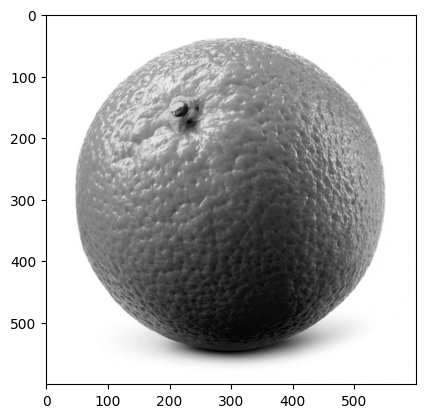

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

img = Image.open("photo.webp")
gray_img = img.convert("L")

img_array = np.array(gray_img, dtype=np.float32)

original_shape = img_array.shape
original_flat = img_array.flatten()

plt.imshow(img_array, cmap="gray")
plt.show()

In [3]:
img = Image.open('photo.webp')
gray_img = img.convert('L')
img_array = np.array(gray_img, dtype = np.float32)

U, S, Vt = np.linalg.svd(img_array, full_matrices=False)



In [4]:
U, s, Vt = np.linalg.svd(img_array, full_matrices=False)

h, w = img_array.shape

list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]

print(list_of_ranks)

[1, 5, 10, 30, 100, 600]


In [5]:
approximations = []

for r in list_of_ranks:
    img_approx = (U[:, :r] * s[:r]) @ Vt[:r, :]
    approximations.append(img_approx)

In [6]:
original_size = h * w

In [7]:
def get_compression(r):
    compressed_size = r * (h + 1 + w) * 4
    compression = original_size / compressed_size
    return compression

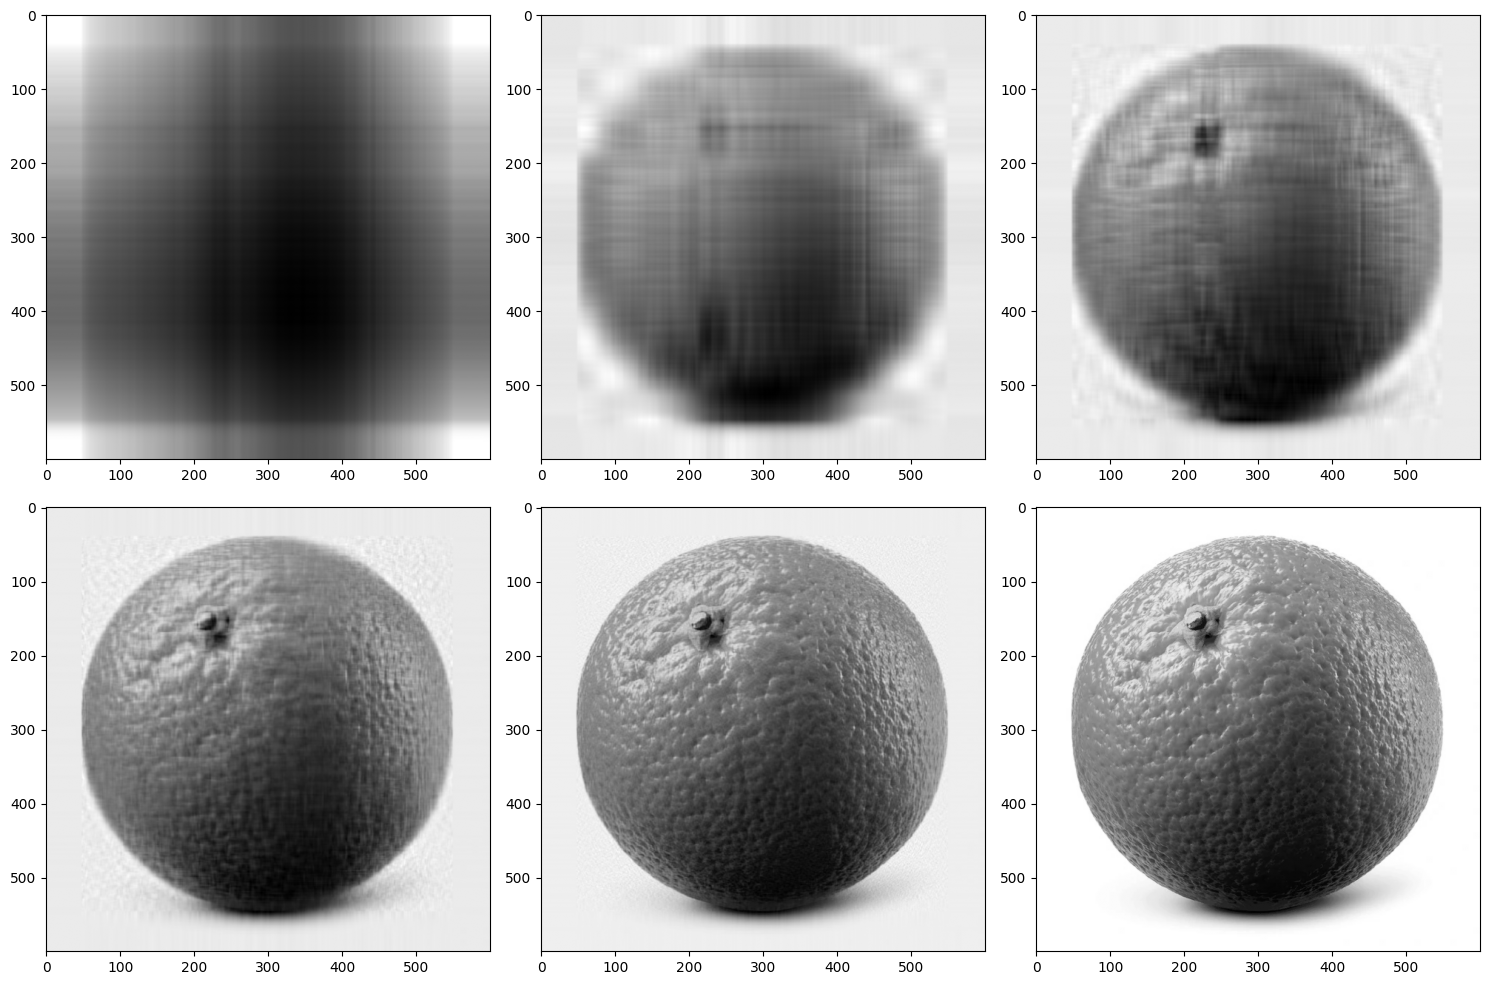

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, r in enumerate(list_of_ranks):
    compression = get_compression(r)

    axes[i].imshow(approximations[i], cmap="gray")

plt.tight_layout()
plt.show()

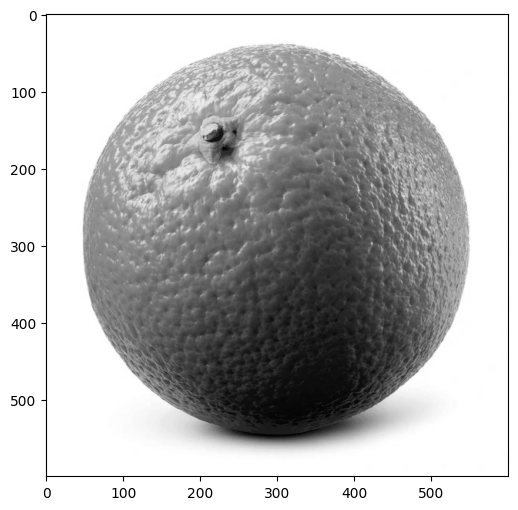

In [14]:
plt.figure(figsize=(6, 6))
plt.imshow(img_array, cmap="gray")
plt.show()

In [17]:
for i, r in enumerate(list_of_ranks):

    compressed_size = r * (h + 1 + w) * 4
    compression = original_size / compressed_size

    mse = mean_squared_error(
        original_flat,
        approximations[i].flatten()
    )

    print(r)
    print(compression)
    print(mse)

1
74.93755203996669
1468.983154296875
5
14.987510407993339
200.04502868652344
10
7.4937552039966695
116.47657775878906
30
2.4979184013322233
55.00098419189453
100
0.7493755203996669
12.962809562683105
600
0.12489592006661115
5.530730984304455e-09


In [11]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, \
        f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка диапазона
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]

    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255)

    assert arr.max() <= 255.1, \
        f"Значения превышают 255 для ранга {r}"

    assert arr.min() >= -0.1, \
        f"Значения меньше 0 для ранга {r}"

# 3. Проверка MSE
mse_list = []

for i in range(len(approximations)):
    mse = mean_squared_error(
        original_flat,
        approximations[i].flatten()
    )

    mse_list.append(mse)

for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, \
        f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!
